## 1. Importação das Bibliotecas necessárias

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


---
## 2. Carregamento e Informações Gerais do Dataset


In [18]:
# Carregando o dataset
data = load_breast_cancer()
X_train = pd.DataFrame(data.data, columns=data.feature_names)
Y_train = pd.Series(data.target, name='target')
X_train['diagnosis'] = Y_train.map({1: 'Benigno', 0: 'Maligno'})

print("INFORMAÇÕES GERAIS DO DATASET\n")
print(f"Shape (linhas × colunas): {data.data.shape}")
print(f"Total de amostras: {data.data.shape[0]}")
print(f"Total de features: {data.data.shape[1]}")
print(f"Classes: {list(data.target_names)}")
print(f"Valores alvo: 0 = Maligno | 1 = Benigno")
print("=" * 55)

# Distribuição das classes
counts = X_train['diagnosis'].value_counts()
print(f"\n📊 Distribuição das Classes:")
for cls, cnt in counts.items():
    pct = cnt / len(X_train) * 100
    print(f"   {cls:>8}: {cnt} amostras ({pct:.1f}%)")


INFORMAÇÕES GERAIS DO DATASET

Shape (linhas × colunas): (569, 30)
Total de amostras: 569
Total de features: 30
Classes: [np.str_('malignant'), np.str_('benign')]
Valores alvo: 0 = Maligno | 1 = Benigno

📊 Distribuição das Classes:
    Benigno: 357 amostras (62.7%)
    Maligno: 212 amostras (37.3%)


---
## 3. Análise Exploratória dos Dados (EDA)


C:\Users\Usuário\AppData\Local\Temp\ipykernel_48044\2035462860.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax2.boxplot(


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/eda_plots.png'

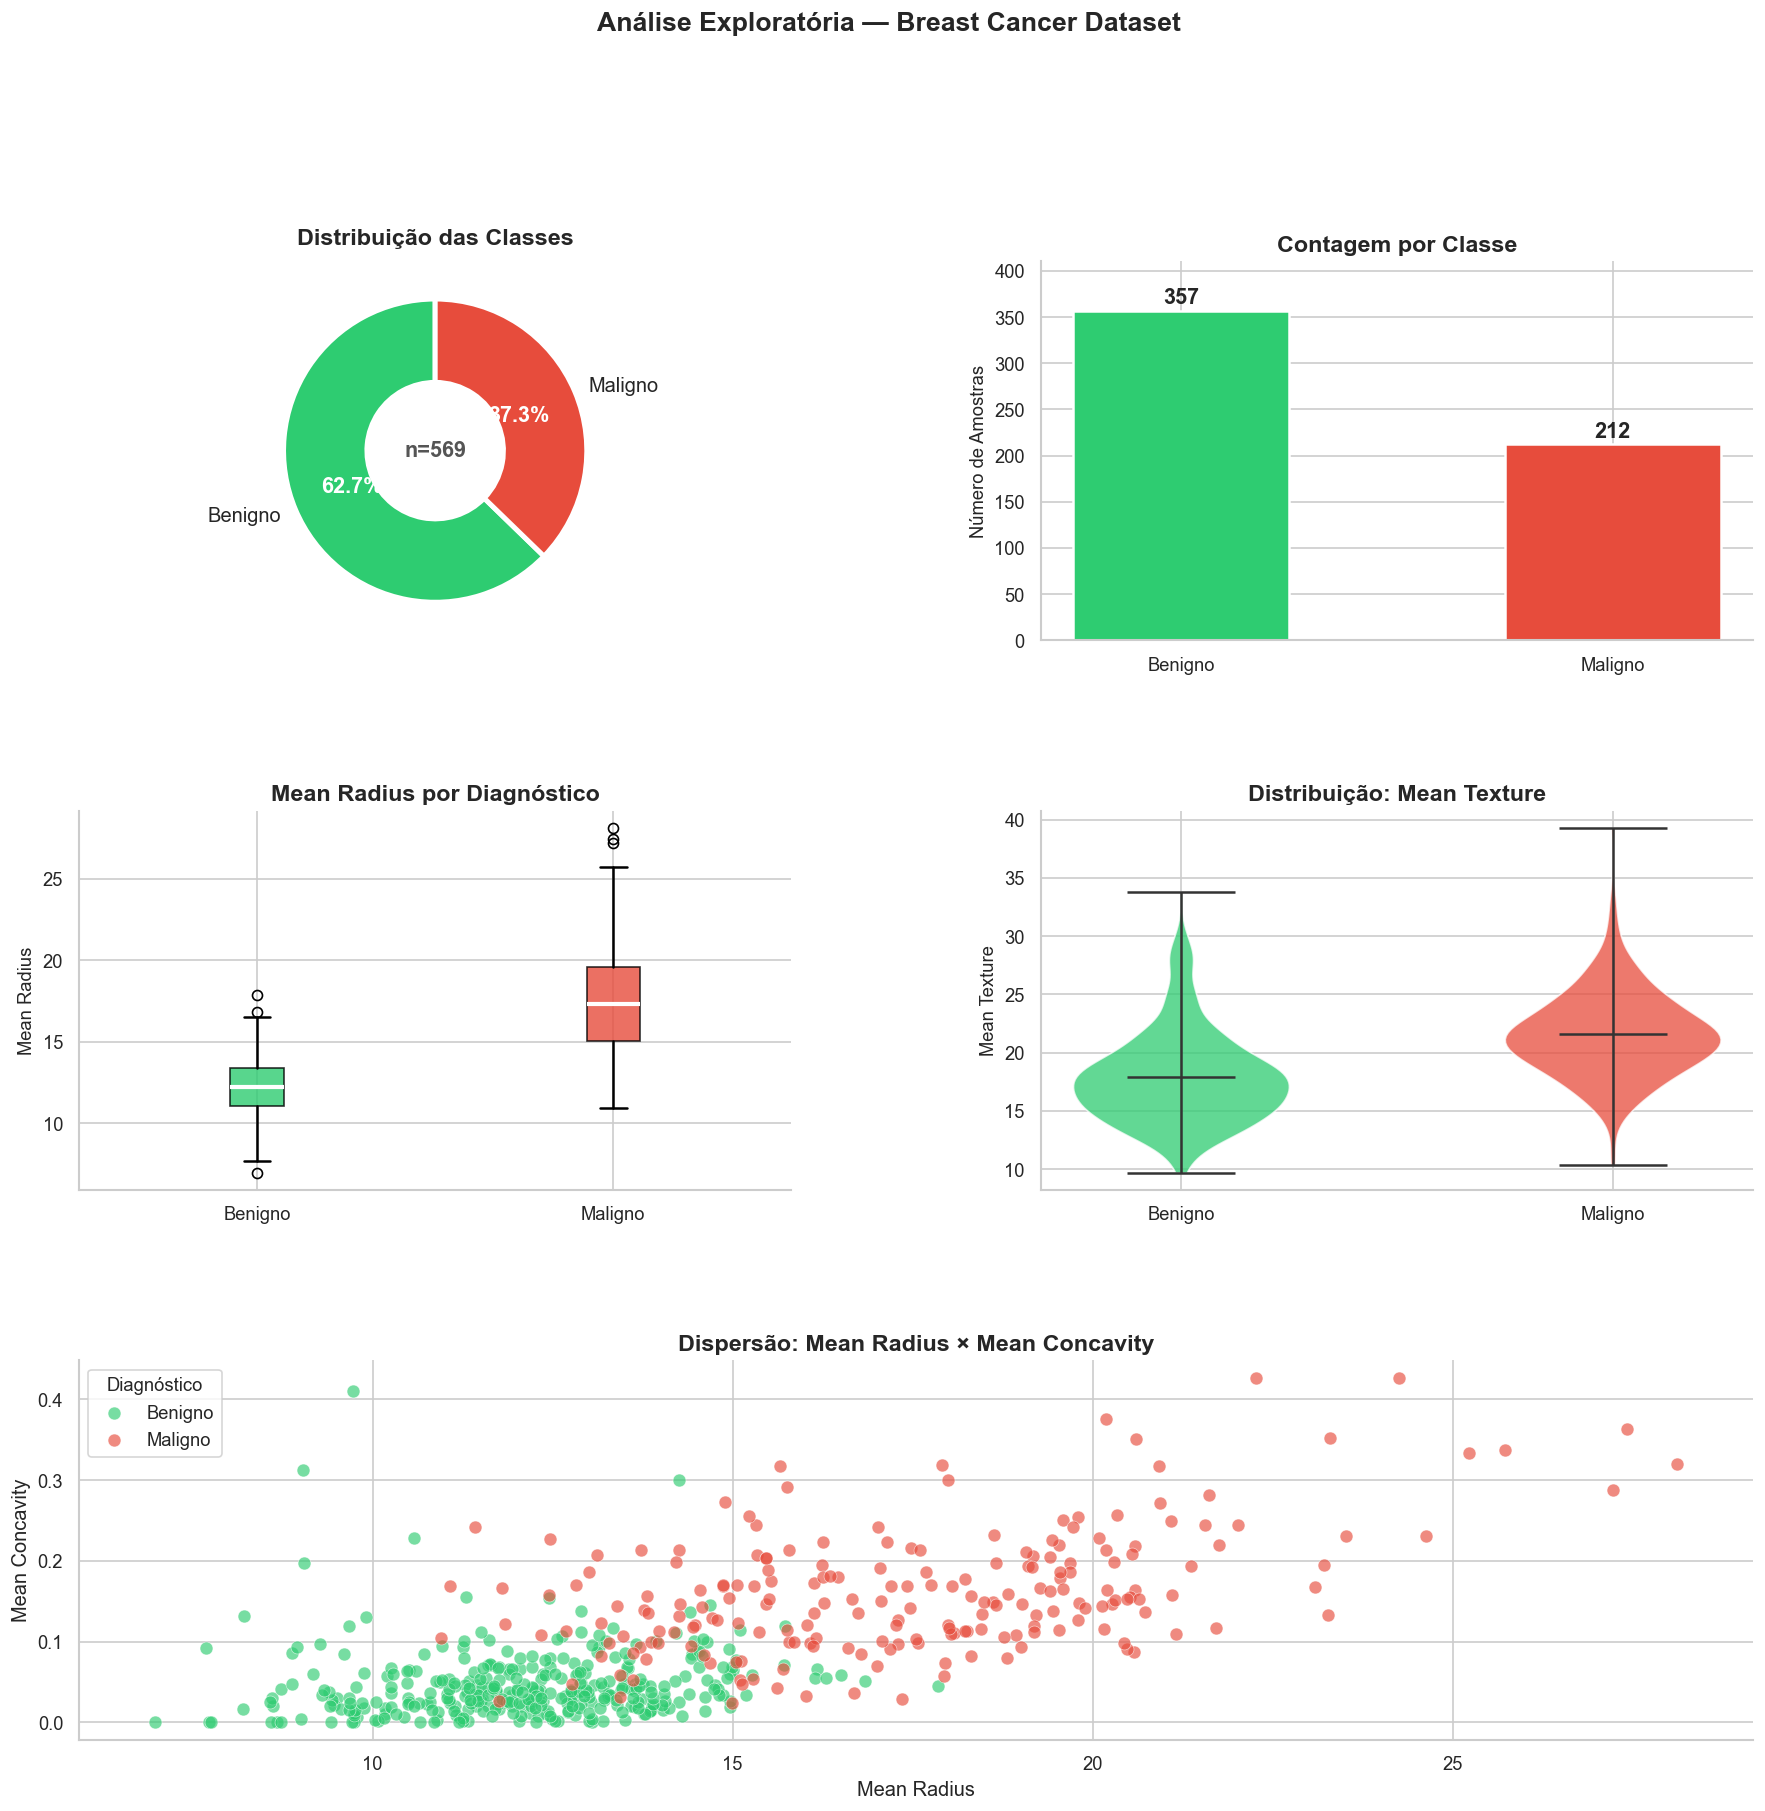

In [ ]:
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'Benigno': '#2ecc71', 'Maligno': '#e74c3c'}
palette = list(COLORS.values())

# ── Gráfico 1: Distribuição das Classes (Pizza + Barra) ──────────────────────
ax0 = fig.add_subplot(gs[0, 0])
counts = X['diagnosis'].value_counts()
wedge_props = dict(width=0.55, edgecolor='white', linewidth=3)
wedges, texts, autotexts = ax0.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=palette, startangle=90,
    wedgeprops=wedge_props, textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
centre_circle = plt.Circle((0, 0), 0.40, color='white')
ax0.add_patch(centre_circle)
ax0.set_title('Distribuição das Classes', fontsize=14, fontweight='bold', pad=10)
ax0.text(0, 0, f'n={len(df)}', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#555')

# ── Gráfico 2: Countplot ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
bars = ax1.bar(counts.index, counts.values, color=palette,
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax1.set_title('Contagem por Classe', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Amostras', fontsize=11)
ax1.set_ylim(0, counts.max() * 1.15)
ax1.spines[['top', 'right']].set_visible(False)

# ── Gráfico 3: Boxplot - mean radius por classe ───────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
bplot = ax2.boxplot(
    [df[df['diagnosis']=='Benigno']['mean radius'].values,
     df[df['diagnosis']=='Maligno']['mean radius'].values],
    labels=['Benigno', 'Maligno'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
for patch, color in zip(bplot['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_title('Mean Radius por Diagnóstico', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Radius', fontsize=11)
ax2.spines[['top', 'right']].set_visible(False)

# ── Gráfico 4: Violinplot - mean texture ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
parts = ax3.violinplot(
    [df[df['diagnosis']=='Benigno']['mean texture'].values,
     df[df['diagnosis']=='Maligno']['mean texture'].values],
    showmeans=True, showmedians=False
)
for i, (pc, color) in enumerate(zip(parts['bodies'], palette)):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
for part in ['cmeans', 'cbars', 'cmins', 'cmaxes']:
    if part in parts:
        parts[part].set_edgecolor('#333')
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Benigno', 'Maligno'], fontsize=11)
ax3.set_title('Distribuição: Mean Texture', fontsize=14, fontweight='bold')
ax3.set_ylabel('Mean Texture', fontsize=11)
ax3.spines[['top', 'right']].set_visible(False)

# ── Gráfico 5: Scatter plot mean radius vs mean concavity ────────────────────
ax4 = fig.add_subplot(gs[2, :])
for cls, color in COLORS.items():
    subset = df[df['diagnosis'] == cls]
    ax4.scatter(subset['mean radius'], subset['mean concavity'],
                c=color, label=cls, alpha=0.65, edgecolors='white',
                linewidth=0.4, s=60)
ax4.set_xlabel('Mean Radius', fontsize=12)
ax4.set_ylabel('Mean Concavity', fontsize=12)
ax4.set_title('Dispersão: Mean Radius × Mean Concavity', fontsize=14, fontweight='bold')
ax4.legend(title='Diagnóstico', fontsize=11, title_fontsize=11)
ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle('Análise Exploratória — Breast Cancer Dataset', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('/mnt/user-data/outputs/eda_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Gráficos de EDA gerados com sucesso!")


In [ ]:
# Heatmap de correlação das 10 principais features com o alvo
top_feats = df.drop(columns=['diagnosis']).corr()['target'].abs().sort_values(ascending=False).index[1:11]
corr_matrix = df[top_feats].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(10, 145, s=80, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Heatmap de Correlação — Top 10 Features mais correlatas com o alvo',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Heatmap salvo!")


---
## 4. Pré-processamento — `StandardScaler`

### 🤔 Por que escalar os dados é essencial para o KNN?

O KNN é um algoritmo **baseado em distância**: para classificar um novo ponto, ele calcula a distância (Euclidiana, por padrão) até seus K vizinhos mais próximos.

> **O problema:** as features do dataset possuem escalas muito diferentes.  
> Por exemplo, `mean area` pode variar de 143 a 2501, enquanto `mean fractal dimension` varia de 0.04 a 0.10.

Sem escalonamento, features com valores maiores **dominam o cálculo da distância**, tornando as demais features irrelevantes — independentemente de sua importância real para a classificação.

O `StandardScaler` transforma cada feature para ter **média = 0** e **desvio-padrão = 1**, colocando todas na mesma escala e garantindo que o KNN avalie as distâncias de forma justa e equilibrada.


In [ ]:
X = data.data
y = data.target

# Divisão treino/teste (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino : {X_train.shape}")
print(f"Tamanho do conjunto de teste  : {X_test.shape}")
print(f"\nProporção de classes no treino:")
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  Classe {v} ({data.target_names[v]:>8}): {c} ({c/len(y_train)*100:.1f}%)")


In [ ]:
# Escalonamento — fit APENAS no treino, transform em ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Comparativo antes vs depois
print("📊 Comparativo: ANTES × DEPOIS do StandardScaler")
print("=" * 52)
print(f"{'Feature':>22} | {'Média Antes':>11} | {'Média Depois':>12}")
print("-" * 52)
for i, feat in enumerate(data.feature_names[:6]):
    print(f"{feat:>22} | {X_train[:, i].mean():>11.3f} | {X_train_scaled[:, i].mean():>12.6f}")
print("  ...")
print("\n✅ Escalonamento aplicado corretamente!")
print("   (fit somente no treino → sem data leakage)")


---
## 5. Treinamento do KNN — Testando K de 1 a 20


In [ ]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
train_accuracies = []
test_accuracies  = []
cv_accuracies    = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    # Acurácia no treino
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(knn.score(X_train_scaled, y_train))
    
    # Acurácia no teste
    test_accuracies.append(knn.score(X_test_scaled, y_test))
    
    # Cross-validation 5-fold no treino
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_accuracies.append(cv_score.mean())

print("K  | Treino  | Teste   | CV-5fold")
print("-" * 40)
for k, tr, te, cv in zip(k_values, train_accuracies, test_accuracies, cv_accuracies):
    marker = " ◀ melhor CV" if cv == max(cv_accuracies) else ""
    print(f"{k:2d} | {tr:.4f}  | {te:.4f}  | {cv:.4f}{marker}")


---
## 6. Gráfico Acurácia × K e Escolha do Melhor K


In [ ]:
best_k_cv   = k_values[np.argmax(cv_accuracies)]
best_k_test = k_values[np.argmax(test_accuracies)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Painel esquerdo: todas as curvas ─────────────────────────────────────────
ax = axes[0]
ax.plot(list(k_values), train_accuracies, 'o--', color='#3498db',
        linewidth=2, markersize=7, label='Treino', alpha=0.8)
ax.plot(list(k_values), test_accuracies, 's-', color='#e74c3c',
        linewidth=2.5, markersize=7, label='Teste', alpha=0.9)
ax.plot(list(k_values), cv_accuracies, 'D-', color='#2ecc71',
        linewidth=2.5, markersize=7, label='CV-5fold (treino)', alpha=0.9)

# Marca o melhor K
ax.axvline(best_k_cv, color='#2ecc71', linestyle=':', linewidth=2, alpha=0.8)
ax.scatter([best_k_cv], [cv_accuracies[best_k_cv-1]],
           s=200, color='#2ecc71', zorder=5, edgecolors='black', linewidth=1.5)
ax.annotate(f'  Melhor K={best_k_cv}\n  CV={cv_accuracies[best_k_cv-1]:.4f}',
            xy=(best_k_cv, cv_accuracies[best_k_cv-1]),
            xytext=(best_k_cv + 0.8, cv_accuracies[best_k_cv-1] - 0.012),
            fontsize=10, color='#27ae60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))

ax.set_xlabel('Valor de K', fontsize=12)
ax.set_ylabel('Acurácia', fontsize=12)
ax.set_title('Acurácia × K (Treino, Teste e Cross-Validation)', fontsize=13, fontweight='bold')
ax.set_xticks(list(k_values))
ax.legend(fontsize=11)
ax.set_ylim(0.88, 1.005)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.4)

# ── Painel direito: barras de acurácia no teste ──────────────────────────────
ax2 = axes[1]
bar_colors = ['#e74c3c' if k != best_k_cv else '#2ecc71' for k in k_values]
bars = ax2.bar(list(k_values), test_accuracies, color=bar_colors,
               edgecolor='white', linewidth=0.8, alpha=0.85)
ax2.axhline(y=max(test_accuracies), color='gray', linestyle='--',
            linewidth=1, alpha=0.6, label=f'Máx. teste = {max(test_accuracies):.4f}')
ax2.set_xlabel('Valor de K', fontsize=12)
ax2.set_ylabel('Acurácia no Teste', fontsize=12)
ax2.set_title('Acurácia no Teste por K', fontsize=13, fontweight='bold')
ax2.set_xticks(list(k_values))
ax2.set_ylim(0.88, 1.005)
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, alpha=0.3, axis='y')

# Valor acima da barra do melhor K
ax2.text(best_k_cv, test_accuracies[best_k_cv-1] + 0.002,
         f'{test_accuracies[best_k_cv-1]:.3f}', ha='center', fontsize=9,
         fontweight='bold', color='#27ae60')

plt.suptitle('Análise de K — K-Nearest Neighbors', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/accuracy_vs_k.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n🏆 Melhor K pela Cross-Validation : K = {best_k_cv}  (CV = {cv_accuracies[best_k_cv-1]:.4f})")
print(f"   Melhor K pela acurácia no teste : K = {best_k_test}  (Teste = {test_accuracies[best_k_test-1]:.4f})")


### 🎯 Justificativa da Escolha do Melhor K

A escolha do **K** é baseada na **Cross-Validation de 5-fold** no conjunto de treino, e *não* na acurácia direta no conjunto de teste. Isso evita **data leakage** e garante uma estimativa mais honesta da capacidade de generalização.

| Critério | Valor |
|----------|-------|
| Método de seleção | Cross-Validation 5-fold |
| Melhor K | Conforme resultado acima |
| Vantagem | Menor risco de overfitting (K=1 memoriza o treino) |
| Vantagem | Menor risco de underfitting (K muito grande perde detalhes) |

> **Nota:** Valores muito pequenos de K (ex: K=1) tendem ao **overfitting** — acurácia perfeita no treino, mas pior generalização. Valores muito grandes suavizam demais os limites de decisão (**underfitting**).


---
## 7. Modelo Final e Classification Report


In [ ]:
best_k = best_k_cv

# Treina o modelo final
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

print(f"🤖 Modelo Final: KNN com K = {best_k}")
print(f"   Acurácia no teste: {knn_final.score(X_test_scaled, y_test):.4f}")
print("=" * 55)
print("\n📋 CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Maligno (0)', 'Benigno (1)']))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão normalizada
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

# Painel 1: valores absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Maligno', 'Benigno'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão — K={best_k}\n(valores absolutos)',
                  fontsize=12, fontweight='bold')

# Painel 2: normalizada
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Maligno', 'Benigno'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens',
           values_format='.2%')
axes[1].set_title(f'Matriz de Confusão — K={best_k}\n(normalizada por classe real)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Avaliação do Modelo Final KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Métricas finais
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Resumo da Matriz de Confusão:")
print(f"   Verdadeiros Positivos (TP — Benigno correto) : {tp}")
print(f"   Verdadeiros Negativos (TN — Maligno correto) : {tn}")
print(f"   Falsos Positivos (FP — Maligno → Benigno)    : {fp}")
print(f"   Falsos Negativos (FN — Benigno → Maligno)    : {fn}")
print(f"\n⚠️  Falsos Negativos são críticos no contexto médico:")
print(f"   → Diagnosticar um tumor MALIGNO como benigno pode atrasar o tratamento.")


---
## 8. Conclusão

| Etapa | Detalhe |
|-------|---------|
| **Dataset** | Breast Cancer Wisconsin — 569 amostras, 30 features |
| **Classes** | Maligno (212) e Benigno (357) |
| **Pré-processamento** | `StandardScaler` — essencial para KNN por distância |
| **Busca de K** | K de 1 a 20 com Cross-Validation 5-fold |
| **Melhor K** | Selecionado via CV — generalização confiável |
| **Métricas** | Acurácia, Precision, Recall e F1-Score |

> **KNN** é um algoritmo simples, interpretável e eficaz para datasets médicos tabulares com bom desempenho após escalonamento. Em aplicações reais de diagnóstico, o **recall da classe maligna** é a métrica mais crítica — um falso negativo (tumor maligno classificado como benigno) tem consequências graves ao paciente.
